In [6]:
countrycode_file_path= r"C:\修論研究\VWT_historical_data\country_list.xlsx"
import pandas as pd
countrycode_df = pd.read_excel(countrycode_file_path)
countrycode_df.head()


,Country name,FAO code,Position,Reporting,Discontinuities,ISO3
0,Afghanistan,2,1,1,NaN,AFG
1,Albania,3,2,1,NaN,ALB
2,Algeria,4,3,1,NaN,DZA
3,American Samoa,5,4,0,NaN,ASM
4,Andorra,6,5,0,NaN,AND


In [8]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# =========================
# SETTINGS
# =========================
year = 1987
crop = 30

# あなたの国マスター（ISO3が入ってるやつ）
COUNTRY_LIST_XLSX = r"C:\修論研究\VWT_historical_data\country_list.xlsx"

# Natural Earth (Admin0 countries) の shp（あなたが読み込めたやつ）
NE_COUNTRIES_SHP = r"C:\修論研究\ne_110m_admin_0_countries.zip!ne_110m_admin_0_countries.shp"

# 南極を画面から切る（表示範囲）
XLIM = (-180, 180)
YLIM = (-60, 85)

TOP_N_PRINT = 20  # 上位輸出先を表示
USE_LOG = True    # ログスケールで塗る

# =========================
# 1) LOAD VWT MATRIX
# =========================
VWT = {}
VWT[(year, crop)]=np.load(r"C:\修論研究\VWT_historical_data\VWT_npy\VWT_{crop}_{year}.npy".format(crop=crop, year=year))

VWTmat = VWT[(year, crop)]
# =========================
# 2) GET JAPAN EXPORT VECTOR
#   行=輸出国、列=輸入国 という前提で「日本の行」を取る
# =========================
# countrycode_df の 1列目が国名（"Japan"）だという前提（あなたのこれまでのコードに合わせる）
japan_index = countrycode_df[countrycode_df.iloc[:, 0] == "Japan"].index[0]
japan_exports = VWTmat[japan_index, :].astype(float)  # 長さ N のはず

print("Japan index:", japan_index)
print("len(japan_exports):", len(japan_exports))

# =========================
# 3) BUILD dest (iso3 + export)
#   country_list.xlsx から ISO3 列を拾って、輸出ベクトルを貼る
# =========================
cl = pd.read_excel(COUNTRY_LIST_XLSX)

# ISO3列名を自動検出（"ISO3" / "iso3" など）
iso3_col = None
for c in cl.columns:
    if str(c).strip().lower() in ["iso3", "iso_a3", "iso-3", "iso_3"]:
        iso3_col = c
        break
if iso3_col is None:
    # それでも無い場合は "ISO3" を含む列名を探す
    for c in cl.columns:
        if "iso3" in str(c).strip().lower():
            iso3_col = c
            break

if iso3_col is None:
    raise ValueError(f"country_list に ISO3 列が見つからない。columns={list(cl.columns)}")

# VWTの国数Nに合わせて切る（重要：country_listがVWTの国順に並んでいる前提）
dest = cl.iloc[:N].copy()
dest = dest[[iso3_col]].rename(columns={iso3_col: "iso3"})
dest["iso3"] = dest["iso3"].astype(str).str.strip()

if len(dest) != len(japan_exports):
    raise ValueError(f"長さが合わない: len(dest)={len(dest)} vs len(japan_exports)={len(japan_exports)}")

dest["export"] = japan_exports

# 上位輸出先チェック（向き検証にも使える）
dest_pos = dest[dest["export"] > 0].sort_values("export", ascending=False)
print("\nTop destinations (iso3, export):")
print(dest_pos.head(TOP_N_PRINT))

# =========================
# 4) LOAD WORLD MAP (Natural Earth shp)
# =========================
world = gpd.read_file(NE_COUNTRIES_SHP)

# ISO3列（world側）を自動検出：あなたのスクショだと SOV_A3 がある
world_iso_candidates = ["SOV_A3", "ISO_A3", "ADM0_A3", "iso_a3", "ISO3", "ISO"]
world_iso_key = next((c for c in world_iso_candidates if c in world.columns), None)
if world_iso_key is None:
    raise ValueError(f"world にISO3列が見つからない。columns={list(world.columns)}")

world[world_iso_key] = world[world_iso_key].astype(str).str.strip()

# =========================
# 5) MERGE (地図に輸出量を貼り付ける)
# =========================
m = world.merge(
    dest[["iso3", "export"]],
    left_on=world_iso_key,
    right_on="iso3",
    how="left"
)

# =========================
# 6) PLOT
# =========================
fig, ax = plt.subplots(1, 1, figsize=(14, 7))
ax.set_axis_off()
ax.set_title(f"Japan rice virtual-water exports by destination | {YEAR} (crop={CROP})", fontsize=14)

# ベース：輸出なし・欠損は薄灰
m.plot(ax=ax, color="lightgrey", linewidth=0.2, edgecolor="white")

# 正の輸出だけ着色
pos = m["export"].fillna(0) > 0
if pos.any():
    if USE_LOG:
        vmin = m.loc[pos, "export"].min()
        vmax = m.loc[pos, "export"].max()
        m.loc[pos].plot(
            ax=ax,
            column="export",
            norm=LogNorm(vmin=vmin, vmax=vmax),
            linewidth=0.2,
            edgecolor="white",
            legend=True,
        )
    else:
        m.loc[pos].plot(
            ax=ax,
            column="export",
            linewidth=0.2,
            edgecolor="white",
            legend=True,
        )

# 日本を枠で強調（world側ISO列でJPNを探す）
jpn = m[m[world_iso_key] == "JPN"]
if len(jpn) > 0:
    jpn.boundary.plot(ax=ax, linewidth=1.8, color="black")

# ★ 南極“を消す”ではなく、表示範囲を切って拡大表示
ax.set_xlim(*XLIM)
ax.set_ylim(*YLIM)

plt.show()

Japan index: 114
len(japan_exports): 255


NameError: name 'N' is not defined

VWTmat shape: (255, 255)
Japan index: 114 (name_col=Country name)
len(japan_exports): 255

Top destinations (iso3, export):
    iso3       export
35   BFA  12604126.00
154  MOZ  10688471.00
58   CIV   9127744.00
55   COD   4737153.40
142  MRT   4659475.50
128  LBR   3887477.30
97   GIN   3389144.00
46   HKG   2894395.90
203  SGP   2186930.00
196  STP   2124787.80
223  TGO   1879803.80
164  NER   1548776.70
41   CPV   1141266.80
12   AUS    926158.89
49   TWN    887917.49
39   CAN    688345.19
48   CHN    679979.88
23   BEN    646518.66
237  USA    566450.73
198  SEN    298760.93
world iso key: SOV_A3


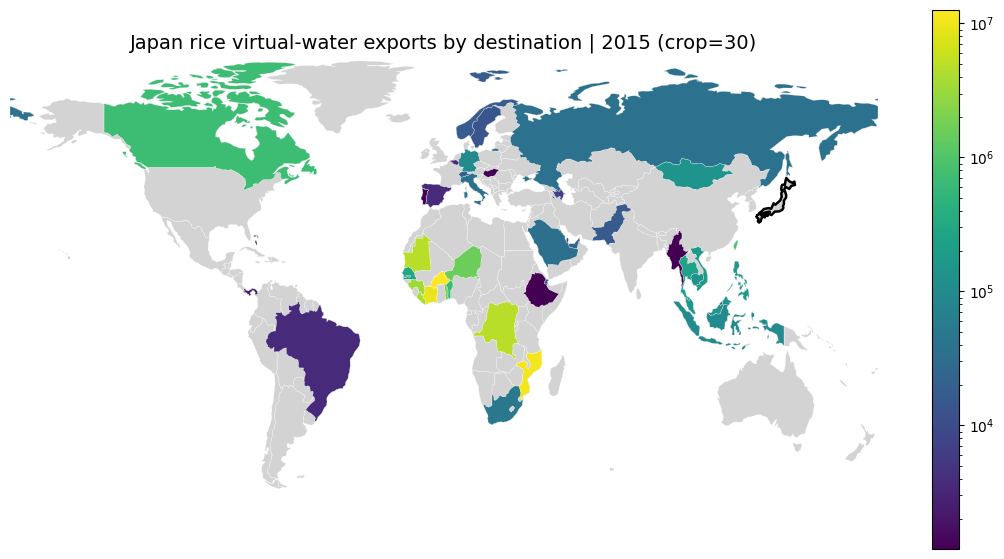

In [10]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# =========================
# SETTINGS
# =========================
year = 2015
crop = 30

# VWT country master (国名・ISO3などが入ってる想定)
COUNTRY_LIST_XLSX = r"C:\修論研究\VWT_historical_data\country_list.xlsx"

# VWT matrix npy
VWT_NPY = rf"C:\修論研究\VWT_historical_data\VWT_npy\VWT_{crop}_{year}.npy"

# Natural Earth countries shapefile in zip (あなたの環境で読める形式のまま)
NE_COUNTRIES_SHP = r"C:\修論研究\ne_110m_admin_0_countries.zip!ne_110m_admin_0_countries.shp"

# map extent (Antarctica cut)
XLIM = (-180, 180)
YLIM = (-60, 85)

TOP_N_PRINT = 20
USE_LOG = True

# =========================
# 1) LOAD VWT MATRIX
# =========================
VWTmat = np.load(VWT_NPY).astype(float)

# 国数
N = VWTmat.shape[0]
if VWTmat.shape[0] != VWTmat.shape[1]:
    print(f"[WARN] VWTmat is not square: {VWTmat.shape}. (row=exporter, col=importer 前提を要確認)")

print("VWTmat shape:", VWTmat.shape)

# =========================
# 2) LOAD COUNTRY LIST (VWTの国順に並んでいる前提)
# =========================
cl = pd.read_excel(COUNTRY_LIST_XLSX)

# --- ISO3列を自動検出 ---
iso3_col = None
for c in cl.columns:
    if str(c).strip().lower() in ["iso3", "iso_a3", "iso-3", "iso_3"]:
        iso3_col = c
        break
if iso3_col is None:
    for c in cl.columns:
        if "iso3" in str(c).strip().lower():
            iso3_col = c
            break
if iso3_col is None:
    raise ValueError(f"country_list に ISO3 列が見つからない。columns={list(cl.columns)}")

# --- 国名列（Japan を探す列）を推定 ---
# まず "Japan" が入ってそうな列を探索。ダメなら1列目を使う。
name_col = None
for c in cl.columns:
    # 文字列化して "Japan" が含まれるかチェック（NaNは除外）
    s = cl[c].dropna().astype(str)
    if (s == "Japan").any():
        name_col = c
        break
if name_col is None:
    name_col = cl.columns[0]  # 最後の手段：1列目が国名の前提

# VWTの国数Nに合わせて切る（country_listがVWT順であることが重要）
clN = cl.iloc[:N].copy()

# Japan index を country_list から取得（countrycode_df 不要）
hit = clN[clN[name_col].astype(str) == "Japan"]
if len(hit) == 0:
    # "Japan" という表記揺れの可能性がある場合の救済（例: "Japan "）
    hit = clN[clN[name_col].astype(str).str.strip() == "Japan"]

if len(hit) == 0:
    raise ValueError(
        f"country_list の列 '{name_col}' に 'Japan' が見つからない。"
        f"（列名候補を確認して。columns={list(cl.columns)}）"
    )

japan_index = int(hit.index[0])
print("Japan index:", japan_index, f"(name_col={name_col})")

# =========================
# 3) GET JAPAN EXPORT VECTOR
#   行=輸出国、列=輸入国 前提で「日本の行」
# =========================
japan_exports = VWTmat[japan_index, :].astype(float)
print("len(japan_exports):", len(japan_exports))

# =========================
# 4) BUILD dest (iso3 + export)
# =========================
dest = clN[[iso3_col]].rename(columns={iso3_col: "iso3"}).copy()
dest["iso3"] = dest["iso3"].astype(str).str.strip()

if len(dest) != len(japan_exports):
    raise ValueError(f"長さが合わない: len(dest)={len(dest)} vs len(japan_exports)={len(japan_exports)}")

dest["export"] = japan_exports

# 上位輸出先（向き・国順の確認用）
dest_pos = dest[dest["export"] > 0].sort_values("export", ascending=False)
print("\nTop destinations (iso3, export):")
print(dest_pos.head(TOP_N_PRINT))

# =========================
# 5) LOAD WORLD MAP (Natural Earth shp)
# =========================
world = gpd.read_file(NE_COUNTRIES_SHP)

# ISO3列（world側）を自動検出
world_iso_candidates = ["SOV_A3", "ISO_A3", "ADM0_A3", "iso_a3", "ISO3", "ISO"]
world_iso_key = next((c for c in world_iso_candidates if c in world.columns), None)
if world_iso_key is None:
    raise ValueError(f"world にISO3列が見つからない。columns={list(world.columns)}")

world[world_iso_key] = world[world_iso_key].astype(str).str.strip()
print("world iso key:", world_iso_key)

# =========================
# 6) MERGE (地図に輸出量を貼り付ける)
# =========================
m = world.merge(
    dest[["iso3", "export"]],
    left_on=world_iso_key,
    right_on="iso3",
    how="left"
)

# =========================
# 7) PLOT
# =========================
fig, ax = plt.subplots(1, 1, figsize=(14, 7))
ax.set_axis_off()
ax.set_title(f"Japan rice virtual-water exports by destination | {year} (crop={crop})", fontsize=14)

# ベース：輸出なし・欠損は薄灰
m.plot(ax=ax, color="lightgrey", linewidth=0.2, edgecolor="white")

# 正の輸出だけ着色
pos = m["export"].fillna(0) > 0
if pos.any():
    if USE_LOG:
        vmin = m.loc[pos, "export"].min()
        vmax = m.loc[pos, "export"].max()
        m.loc[pos].plot(
            ax=ax,
            column="export",
            norm=LogNorm(vmin=vmin, vmax=vmax),
            linewidth=0.2,
            edgecolor="white",
            legend=True,
        )
    else:
        m.loc[pos].plot(
            ax=ax,
            column="export",
            linewidth=0.2,
            edgecolor="white",
            legend=True,
        )
else:
    print("[WARN] export > 0 が1つも無い（向きが逆、year/cropが違う、Japan indexが違う等を疑う）")

# 日本を枠で強調（world側ISO列でJPNを探す）
jpn = m[m[world_iso_key] == "JPN"]
if len(jpn) > 0:
    jpn.boundary.plot(ax=ax, linewidth=1.8, color="black")
else:
    print("[WARN] world側で JPN が見つからない（ISO列キーの問題の可能性）")

# 南極“を消す”ではなく表示範囲を切る
ax.set_xlim(*XLIM)
ax.set_ylim(*YLIM)

plt.show()